In [1]:
from train import compute_and_plot_predictions
from utils.data import load_dataset
from utils.metrics import compute_metrics

from matplotlib import colors as mcolors
from keras.api.models import load_model
import matplotlib.pyplot as plt
from typing import Tuple
import pandas as pd
import numpy as np
import argparse
import json
import os


def parse_arguments() -> argparse.Namespace:
  """
  Parse input arguments
  """
  parser = argparse.ArgumentParser(
    description="Postprocessing"
  )
  parser.add_argument(
    "-f", "--base_folder", 
    help="Paths to the base experiment folder", 
    type=str,
    required=True
  )
  parser.add_argument(
    "-m", "--merge_strategy", 
    help="Merge strategy adopted by GL experiments", 
    type=str,
    default=None
  )
  parser.add_argument(
    "--nodes", 
    help="Indices of nodes to consider (default: [0,10) + 'centralized')", 
    nargs="+",
    default="all"
  )
  parser.add_argument(
    "--networks", 
    help="Network indices (default: [0,10)", 
    nargs="+",
    default="all"
  )
  args, _ = parser.parse_known_args()
  return args


def compute_predictions(
    models: dict, all_X_Y_data: dict, plot_folders: str, tasks: dict
  ) -> Tuple[pd.DataFrame, pd.DataFrame]:
  # compute and plot predictions
  all_predictions = pd.DataFrame()
  all_metrics = {"key": [], "node": [], "seed": [], "metrics": []}
  for node, sim_models in models.items():
    for seed, model in sim_models.items():
      X_Y_data = all_X_Y_data[node][seed]
      predictions = compute_and_plot_predictions(
        X_Y_data, 
        model, 
        plot_folders[seed], 
        str(node), 
        tasks["Multi_Task_regression"]["targets"]
      )
      # get train, val, test
      for key, pred in predictions.items():
        Y_real = X_Y_data[key][1]
        # convert to dataframe and save
        df = get_predictions_df(Y_real, pred, tasks)
        df["key"] = key
        df["node"] = node
        df["seed"] = seed
        all_predictions = pd.concat([all_predictions, df], ignore_index = True)
        # compute metrics
        metrics = compute_metrics(Y_real, pred)
        all_metrics["key"].append(key)
        all_metrics["node"].append(node)
        all_metrics["seed"].append(seed)
        all_metrics["metrics"].append(metrics)
  # extract some surely-relevant metrics
  all_metrics = get_metrics_df(all_metrics)
  return all_predictions, all_metrics


def load_gossip_models_and_data(
    base_folder: str, network_index: int, merge_strategy: str
  ) -> Tuple[dict, dict, dict]:
  # data folder
  data_folder = os.path.join(base_folder, str(network_index))
  # loop over simulations
  models = {}
  all_X_Y_data = {}
  plot_folders = {}
  for foldername in os.listdir(base_folder):
    if foldername.startswith(f"gossip-MergeStrategy.{merge_strategy}"):
      # get seed
      internal_seed = int(foldername.removeprefix(
        f"gossip-MergeStrategy.{merge_strategy}_"
      ))
      # define folders and files
      models_folder = os.path.join(
        base_folder, foldername, str(network_index), "models"
      )
      common_test_file = os.path.join(
        base_folder, foldername, str(network_index), "common_test_set.json"
      )
      plot_folder = os.path.join(
        base_folder, foldername, str(network_index), "plots"
      )
      plot_folders[internal_seed] = plot_folder
      # load common test set
      X_test, Y_test = None, None
      with open(common_test_file, "r") as istream:
        common_test_set = json.load(istream)
        X_test = np.array(common_test_set["X_test"])
        Y_test = np.array(common_test_set["Y_test"])
      # load models and nodes-specific data
      for model_filename in os.listdir(models_folder):
        # get node id
        node = int(model_filename.split(".")[0])
        # load model
        model = load_model(os.path.join(models_folder, model_filename))
        if node not in models:
          models[node] = {}
        models[node][internal_seed] = model
        # load data
        train, val, test = load_dataset(data_folder, node)
        if node not in all_X_Y_data:
          all_X_Y_data[node] = {}
        all_X_Y_data[node][internal_seed] = {
          "train": train,
          "val": val,
          "test": test,
          "common_test": [X_test, Y_test]
        }
  return models, all_X_Y_data, plot_folders


def get_metrics_df(metrics_data: pd.DataFrame) -> pd.DataFrame:
  all_metrics = pd.DataFrame(metrics_data)
  all_metrics["mape"] = [m.mape * 100 for m in all_metrics["metrics"]]
  all_metrics["mse"] = [m.mse for m in all_metrics["metrics"]]
  all_metrics["r2"] = [m.r2 for m in all_metrics["metrics"]]
  all_metrics["accuracy"] = [
    m.cls_report["accuracy"] for m in all_metrics["metrics"]
  ]
  return all_metrics


def get_predictions_df(
    Y_real: np.array, pred, tasks: dict
  ) -> pd.DataFrame:
  real_df_reg = pd.DataFrame(
    Y_real[:,:-1], 
    columns = tasks["Multi_Task_regression"]["targets"]
  )
  real_df_cls = pd.DataFrame(
    Y_real[:,-1], 
    columns = tasks["Multi_Task_classification"]["targets"]
  )
  pred_df_reg = pd.DataFrame(
    pred[0], 
    columns = tasks["Multi_Task_regression"]["targets"]
  )
  pred_df_cls = pd.DataFrame(
    (pred[1] > 0.5).astype(int), 
    columns = tasks["Multi_Task_classification"]["targets"]
  )
  # save
  df = pd.concat(
    [
      real_df_reg.join(
        pred_df_reg, lsuffix = "_real", rsuffix = "_pred"
      ),
      real_df_cls.join(
        pred_df_cls, lsuffix = "_real", rsuffix = "_pred"
      )
    ],
    axis = "columns"
  )
  return df


def load_existing_predictions(
    data_folder: str, nodes: list, tasks: dict
  ) -> Tuple[pd.DataFrame, pd.DataFrame]:
  # loop over nodes
  all_predictions = pd.DataFrame()
  all_metrics = {"key": [], "node": [], "seed": [], "metrics": []}
  for node in nodes:
    # load data
    data = load_dataset(data_folder, node)
    # load predictions
    for foldername in os.listdir(data_folder):
      # loop over simulations
      if foldername.startswith("results_"):
        internal_seed = int(foldername.replace("results_", ""))
        # load
        pred_file = ""
        if node != "centralized":
          pred_file = os.path.join(
            data_folder, foldername, f"{node}_single_pred.json"
          )
        else:
          pred_file = os.path.join(
            data_folder, foldername, "centralized_pred.json"
          )
        predictions = {}
        with open(pred_file, "r") as istream:
          predictions = json.load(istream)
        # get train, val, test
        for idx, (key, pred_dict) in enumerate(predictions.items()):
          Y_real = data[idx][1]
          pred = {int(k): np.array(v) for k, v in pred_dict.items()}
          # convert to dataframe and save
          df = get_predictions_df(Y_real, pred, tasks)
          df["key"] = key
          df["node"] = node
          df["seed"] = internal_seed
          all_predictions = pd.concat(
            [all_predictions, df], ignore_index = True
          )
          # compute metrics
          metrics = compute_metrics(Y_real, pred)
          all_metrics["key"].append(key)
          all_metrics["node"].append(node)
          all_metrics["seed"].append(internal_seed)
          all_metrics["metrics"].append(metrics)
  # extract some surely-relevant metrics
  all_metrics = get_metrics_df(all_metrics)
  return all_predictions, all_metrics


def load_single_centralized_models(data_folder: str, nodes: list) -> dict:
  models = {}
  for node in nodes:
    # loop over simulations
    models[node] = {}
    for foldername in os.listdir(data_folder):
      if foldername.startswith("results_"):
        seed = int(foldername.replace("results_", ""))
        # get model filename
        model_filename = None
        if str(node) != "centralized":
          model_filename = os.path.join(
            data_folder, foldername, f"{node}_single.keras"
          )
        else:
          model_filename = os.path.join(
            data_folder, foldername, "centralized.keras"
          )
        # load model
        model = load_model(model_filename)
        models[node][seed] = model
  return models


def load_single_data(data_folder: str, nodes: list) -> dict:
  single_X_Y_data = {}
  for node in nodes:
    _, _, test = load_dataset(data_folder, node)
    single_X_Y_data[node] = {"test": test}
  return single_X_Y_data


def plot_metrics(
    all_metrics: pd.DataFrame, 
    experiment_idx: int, 
    relevant_metrics: list,
    output_folder: str = None
  ):
  # rename 'centralized' to 'C' (if available)
  if (all_metrics["node"] == "centralized").any():
    all_metrics.replace("centralized", "C", inplace = True)
  # get maximum and minimum number of nodes
  minnode = min([int(n) for n in all_metrics["node"].unique() if n != "C"])
  maxnode = max([int(n) for n in all_metrics["node"].unique() if n != "C"])
  # plot
  nrows = len(relevant_metrics)
  ncols = len(all_metrics["key"].unique())
  _, axs = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize = (8 * ncols, 3 * nrows),
    sharex = True,
    sharey = "row"
  )
  cidx = 0
  for key, metrics in all_metrics.groupby("key"):
    cax = axs if ncols == 1 else axs[:,cidx]
    ridx = 0
    for metric_name in relevant_metrics:
      rax = cax if nrows == 1 else cax[ridx]
      metrics.plot.bar(
        x = "node",
        y = metric_name,
        rot = 0,
        fontsize = 14,
        grid = True,
        label = None,
        ax = rax
      )
      rax.hlines(
        xmin = minnode,
        xmax = maxnode,
        y = float(metrics[metrics["node"] != "C"][metric_name].mean()),
        color = mcolors.TABLEAU_COLORS["tab:red"],
        linewidth = 2
      )
      if ridx == 0:
        rax.set_title(key, fontsize = 14)
      if cidx == 0:
        rax.set_ylabel(metric_name, fontsize = 14)
      if ridx == nrows - 1:
        rax.set_xlabel("Node", fontsize = 14)
      ridx += 1
    cidx += 1
  if output_folder is not None:
    plt.savefig(
      os.path.join(
        output_folder, f"{'_'.join(relevant_metrics)}_{experiment_idx}.png"
      ),
      dpi = 300,
      format = "png",
      bbox_inches = "tight"
    )
    plt.close()
  else:
    plt.show()


def plot_predictions(
    all_predictions: pd.DataFrame, 
    tasks: dict, 
    output_folder: str = None
  ):
  for (node, key), full_pred in all_predictions.groupby(["node", "key"]):
    # -- regression
    for target in tasks["Multi_Task_regression"]["targets"]:
      real = full_pred[f"{target}_real"]
      pred = full_pred[f"{target}_pred"]
      _, ax = plt.subplots(figsize = (7,3))
      ax.plot(
        real, pred, '.', label = None
      )
      ymin = float(real.min())
      ymax = float(real.max())
      ax.plot(
        np.linspace(ymin,ymax,1000), np.linspace(ymin,ymax,1000), "k--"
      )
      plt.title(f"{node}, {key}, {target}")
      if output_folder is not None:
        plt.savefig(
          os.path.join(
            output_folder, 
            f"predictions_{node}_{key}_{target}.png"
          ),
          dpi = 300,
          format = "png",
          bbox_inches = "tight"
        )
        plt.close()
      else:
        plt.show()

In [6]:
base_folder = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850"
merge_strategy = "IMPROVED_OVERWRITE"
nodes = "all"
networks = [0]  # "all"
recompute_all = False

if not isinstance(nodes, list):
    if str(nodes) != "all":
        nodes = [nodes]
    else:
        nodes = list(range(9)) + ["centralized"]

if not isinstance(networks, list):
    if str(networks) != "all":
        networks = [networks]
    else:
        networks = list(range(10))

# run
all_test_avg_metrics = pd.DataFrame()

for idx in networks:

    # single/centralized predictions
    data_folder = os.path.join(base_folder, str(idx))

    tasks = {}

    with open(os.path.join(data_folder, "tasks.json"), "r") as istream:
        tasks = json.load(istream)

    sc_metrics = None

    if not recompute_all and os.path.exists(
        os.path.join(data_folder, "sc_metrics.csv")
    ):

        sc_metrics = pd.read_csv(
            os.path.join(data_folder, "sc_metrics.csv")
        )

    else:

        sc_predictions, sc_metrics = load_existing_predictions(
            data_folder,
            nodes,
            tasks
        )

        sc_metrics.to_csv(
            os.path.join(data_folder, "sc_metrics.csv"),
            index=False
        )

        # plot_predictions_with_average(sc_predictions, 4, data_folder)

        plot_metrics(
            sc_metrics.groupby(
                ["node", "key"]
            ).mean(numeric_only=True).reset_index().drop(
                "seed",
                axis="columns"
            ),
            idx,
            ["mse", "mape", "r2", "accuracy"],
            data_folder
        )

    # gossip predictions and metrics (if any)
    gossip_predictions, gossip_metrics, sc_generalized_metrics = [None] * 3

    sc_models = load_single_centralized_models(
        data_folder,
        nodes
    )

    if merge_strategy is not None:

        # -- load data
        g_models, g_X_Y_data, gplot_folders = load_gossip_models_and_data(
            base_folder,
            idx,
            merge_strategy
        )

        # -- compute predictions and metrics
        if not recompute_all and os.path.exists(
            os.path.join(
                base_folder,
                f"{idx}_gossip_metrics_{merge_strategy}.csv"
            )
        ):

            gossip_metrics = pd.read_csv(
                os.path.join(
                    base_folder,
                    f"{idx}_gossip_metrics_{merge_strategy}.csv"
                )
            )

        else:

            gossip_predictions, gossip_metrics = compute_predictions(
                g_models,
                g_X_Y_data,
                gplot_folders,
                tasks
            )

            for seed, plot_folder in gplot_folders.items():

                plot_predictions(
                    gossip_predictions[
                        gossip_predictions["seed"] == seed
                    ],
                    tasks,
                    plot_folder
                )

                plot_metrics(
                    gossip_metrics[
                        gossip_metrics["seed"] == seed
                    ],
                    idx,
                    ["mse", "mape", "r2", "accuracy"],
                    plot_folder
                )

            gossip_metrics.to_csv(
                os.path.join(
                    base_folder,
                    f"{idx}_gossip_metrics_{merge_strategy}.csv"
                ),
                index=False
            )

ValueError: Input contains NaN.

In [7]:
def debug_compute_predictions(models, all_X_Y_data, plot_folders, tasks):
    for node, sim_models in models.items():
        for seed, model in sim_models.items():
            print("\n" + "=" * 80)
            print(f"NODE={node} | SEED={seed}")
            print("=" * 80)

            X_Y_data = all_X_Y_data[node][seed]

            predictions = compute_and_plot_predictions(
                X_Y_data,
                model,
                plot_folders[seed],
                str(node),
                tasks["Multi_Task_regression"]["targets"]
            )

            for key, pred in predictions.items():
                Y_real = np.array(X_Y_data[key][1])
                pred_0 = np.array(pred[0])
                pred_1 = np.array(pred[1])

                print(f"\nSplit: {key}")
                print("Y_real shape:", Y_real.shape)
                print("pred[0] shape:", pred_0.shape)
                print("pred[1] shape:", pred_1.shape)

                print("NaN Y_real:", np.isnan(Y_real).sum())
                print("NaN pred[0]:", np.isnan(pred_0).sum())
                print("NaN pred[1]:", np.isnan(pred_1).sum())

                print("Inf Y_real:", np.isinf(Y_real).sum())
                print("Inf pred[0]:", np.isinf(pred_0).sum())
                print("Inf pred[1]:", np.isinf(pred_1).sum())

                if (
                    np.isnan(Y_real).any()
                    or np.isnan(pred_0).any()
                    or np.isnan(pred_1).any()
                    or np.isinf(Y_real).any()
                    or np.isinf(pred_0).any()
                    or np.isinf(pred_1).any()
                ):
                    print("\n>>> ERRORE TROVATO QUI <<<")
                    print("node:", node)
                    print("seed:", seed)
                    print("key:", key)

                    if np.isnan(Y_real).any():
                        print("Problema: Y_real contiene NaN")

                    if np.isnan(pred_0).any():
                        print("Problema: pred[0] contiene NaN")

                    if np.isnan(pred_1).any():
                        print("Problema: pred[1] contiene NaN")

                    if np.isinf(Y_real).any():
                        print("Problema: Y_real contiene Inf")

                    if np.isinf(pred_0).any():
                        print("Problema: pred[0] contiene Inf")

                    if np.isinf(pred_1).any():
                        print("Problema: pred[1] contiene Inf")

                    return node, seed, key

                try:
                    _ = compute_metrics(Y_real, pred)
                    print("metrics OK")
                except Exception as e:
                    print("\n>>> compute_metrics crasha qui <<<")
                    print("node:", node)
                    print("seed:", seed)
                    print("key:", key)
                    print("errore:", repr(e))
                    return node, seed, key

    print("\nNessun NaN/Inf trovato.")
    return None

345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


KeyboardInterrupt: 

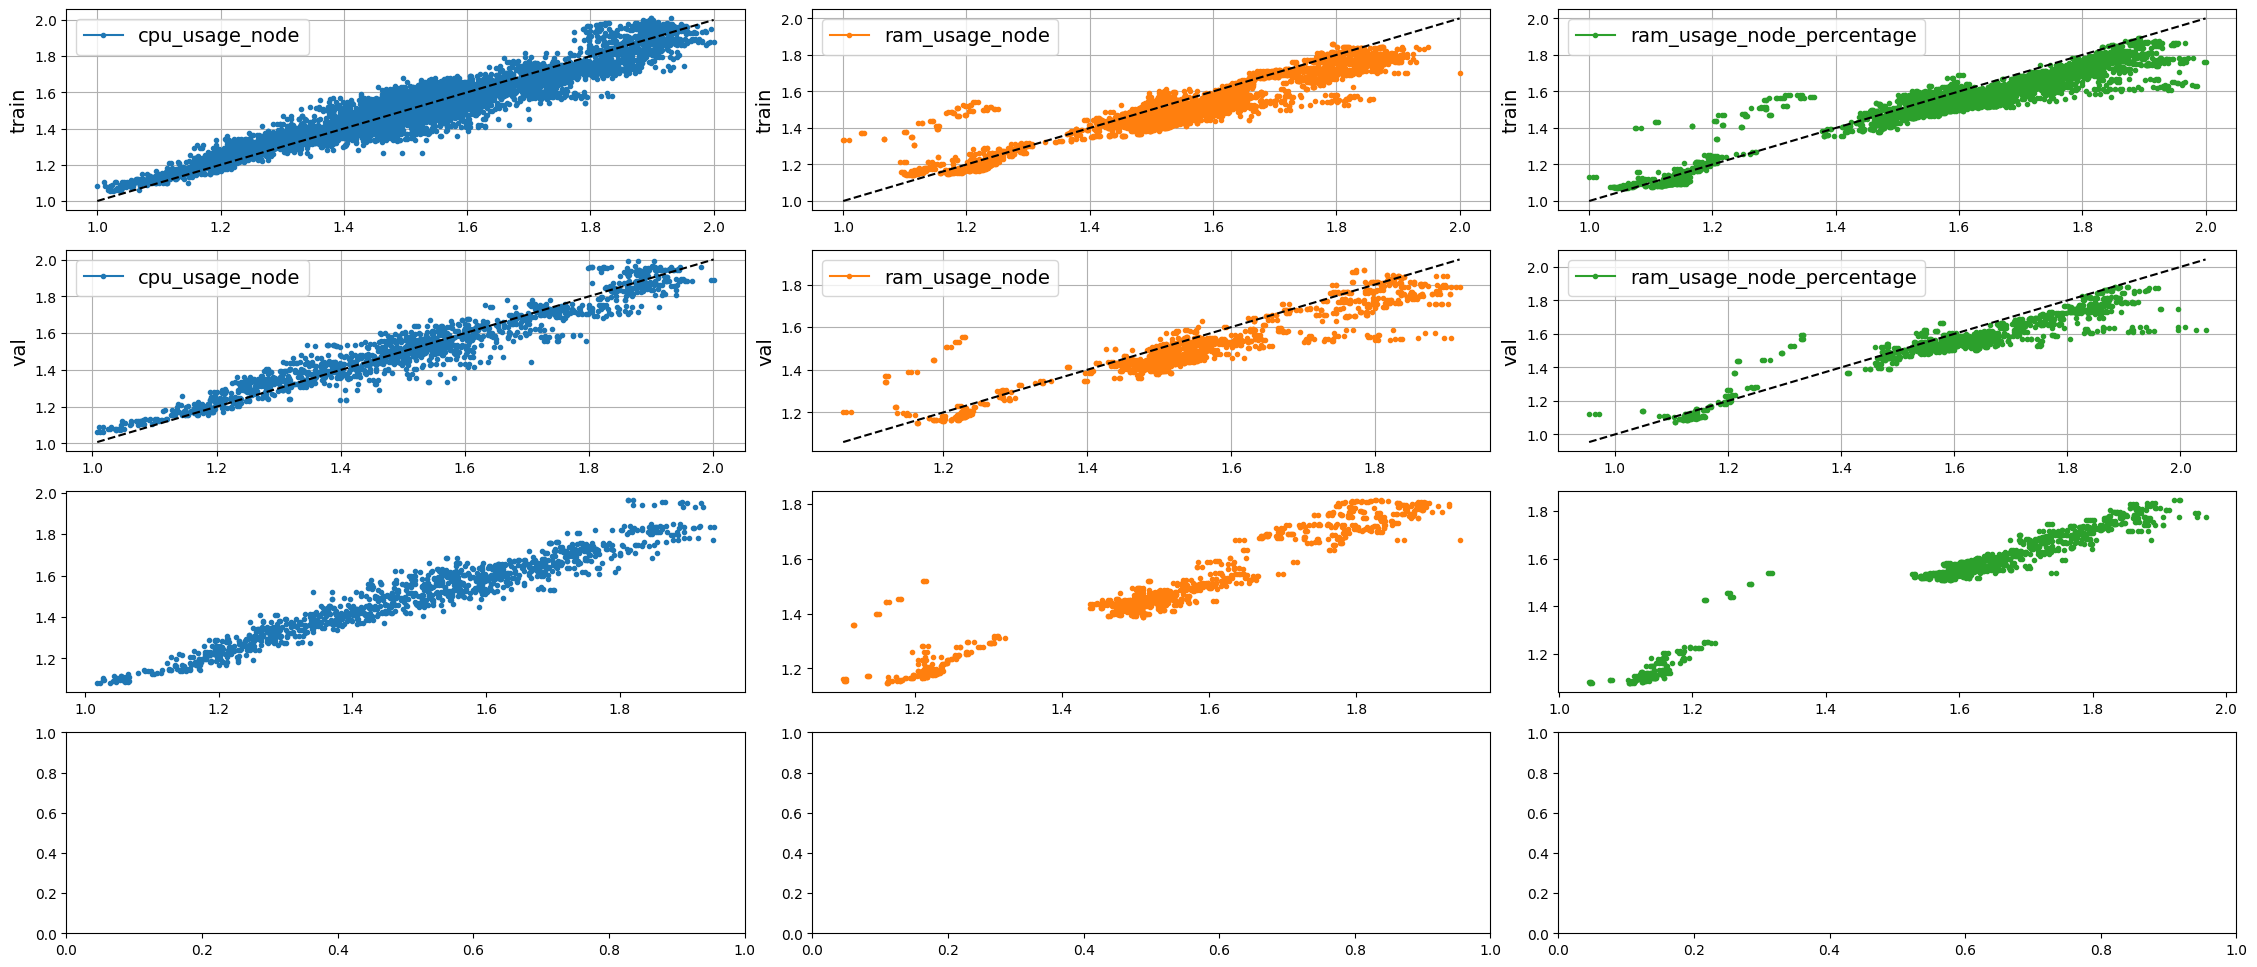

In [8]:
gossip_predictions, gossip_metrics = compute_predictions(
    g_models,
    g_X_Y_data,
    gplot_folders,
    tasks
)

In [9]:
debug_compute_predictions(
    g_models,
    g_X_Y_data,
    gplot_folders,
    tasks
)


NODE=9 | SEED=8784
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Split: train
Y_real shape: (11028, 4)
pred[0] shape: (11028, 3)
pred[1] shape: (11028, 1)
NaN Y_real: 15588
NaN pred[0]: 0
NaN pred[1]: 0
Inf Y_real: 0
Inf pred[0]: 0
Inf pred[1]: 0

>>> ERRORE TROVATO QUI <<<
node: 9
seed: 8784
key: train
Problema: Y_real contiene NaN


(9, 8784, 'train')

In [ ]:
data_folder =
/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/0

In [ ]:
data=/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/0/9_data.json

In [10]:
import json
import numpy as np
import pandas as pd

file = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/0/9_data.json"

# =========================
# LOAD JSON
# =========================
with open(file, "r") as f:
    data = json.load(f)

print("FILE CARICATO\n")


FILE CARICATO



In [11]:
# =========================
# DEBUG FUNCTION
# =========================
def debug_array(name, arr):
    arr = np.array(arr)

    print("=" * 80)
    print(f"DEBUG: {name}")
    print("=" * 80)

    print("shape:", arr.shape)
    print("dtype:", arr.dtype)

    # NaN
    nan_count = np.isnan(arr).sum()

    # Inf
    inf_count = np.isinf(arr).sum()

    print("NaN totali:", nan_count)
    print("Inf totali:", inf_count)

    if nan_count > 0:
        print("\n>>> POSIZIONI NaN <<<")

        nan_positions = np.argwhere(np.isnan(arr))

        print("Numero posizioni:", len(nan_positions))

        # mostra prime 20
        for pos in nan_positions[:20]:
            print(tuple(pos))

        # colonne con NaN
        if arr.ndim == 2:
            df = pd.DataFrame(arr)

            print("\nNaN per colonna:")
            print(df.isna().sum())

            print("\nPrime righe problematiche:")
            print(df[df.isna().any(axis=1)].head())

    if inf_count > 0:
        print("\n>>> POSIZIONI INF <<<")

        inf_positions = np.argwhere(np.isinf(arr))

        for pos in inf_positions[:20]:
            print(tuple(pos))

    print("\n")

In [12]:
# =========================
# DEBUG ALL DATA
# =========================
for key in data.keys():
    debug_array(key, data[key])

DEBUG: X_train
shape: (11028, 3, 8)
dtype: float64
NaN totali: 0
Inf totali: 0


DEBUG: Y_train
shape: (11028, 4)
dtype: float64
NaN totali: 15588
Inf totali: 0

>>> POSIZIONI NaN <<<
Numero posizioni: 15588
(np.int64(5832), np.int64(0))
(np.int64(5832), np.int64(1))
(np.int64(5832), np.int64(2))
(np.int64(5833), np.int64(0))
(np.int64(5833), np.int64(1))
(np.int64(5833), np.int64(2))
(np.int64(5834), np.int64(0))
(np.int64(5834), np.int64(1))
(np.int64(5834), np.int64(2))
(np.int64(5835), np.int64(0))
(np.int64(5835), np.int64(1))
(np.int64(5835), np.int64(2))
(np.int64(5836), np.int64(0))
(np.int64(5836), np.int64(1))
(np.int64(5836), np.int64(2))
(np.int64(5837), np.int64(0))
(np.int64(5837), np.int64(1))
(np.int64(5837), np.int64(2))
(np.int64(5838), np.int64(0))
(np.int64(5838), np.int64(1))

NaN per colonna:
0    5196
1    5196
2    5196
3       0
dtype: int64

Prime righe problematiche:
       0   1   2    3
5832 NaN NaN NaN  1.0
5833 NaN NaN NaN  1.0
5834 NaN NaN NaN  1.0
5835 

# test

In [13]:
# =====================================================
# CELLA 1 — IMPORT
# =====================================================

import json
import numpy as np
import pandas as pd

In [14]:
# =====================================================
# CELLA 2 — LOAD FILE
# =====================================================

file = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/0/9_data.json"

with open(file, "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['X_train', 'Y_train', 'X_val', 'Y_val', 'X_test', 'Y_test'])


In [15]:
# =====================================================
# CELLA 3 — CARICA Y_train
# =====================================================

Y_train = np.array(data["Y_train"])

print("Shape:", Y_train.shape)
print("Dtype:", Y_train.dtype)

Shape: (11028, 4)
Dtype: float64


In [16]:
# =====================================================
# CELLA 4 — CONTA NaN
# =====================================================

print("NaN totali:")
print(np.isnan(Y_train).sum())

print("\nInf totali:")
print(np.isinf(Y_train).sum())

NaN totali:
15588

Inf totali:
0


In [17]:
# =====================================================
# CELLA 5 — CREA DATAFRAME
# =====================================================

df = pd.DataFrame(
    Y_train,
    columns=[
        "target_0",
        "target_1",
        "target_2",
        "classification"
    ]
)

df.head()

,target_0,target_1,target_2,classification
0,1.742072,1.807405,1.756414,0.0
1,1.804291,1.788900,1.736749,0.0
2,1.748570,1.793605,1.741819,0.0
3,1.830055,1.823535,1.774083,0.0
4,1.833765,1.813004,1.763240,0.0


In [18]:
# =====================================================
# CELLA 6 — NaN PER COLONNA
# =====================================================

df.isna().sum()

target_0          5196
target_1          5196
target_2          5196
classification       0
dtype: int64

In [19]:
# =====================================================
# CELLA 7 — RIGHE CON NaN
# =====================================================

nan_rows = df[df.isna().any(axis=1)]

print("Numero righe problematiche:")
print(len(nan_rows))

nan_rows.head(20)

Numero righe problematiche:
5196


,target_0,target_1,target_2,classification
5832,NaN,NaN,NaN,1.0
5833,NaN,NaN,NaN,1.0
5834,NaN,NaN,NaN,1.0
5835,NaN,NaN,NaN,1.0
5836,NaN,NaN,NaN,1.0
5837,NaN,NaN,NaN,1.0
5838,NaN,NaN,NaN,1.0
5839,NaN,NaN,NaN,1.0
5840,NaN,NaN,NaN,1.0
5841,NaN,NaN,NaN,1.0


In [21]:
# =====================================================
# CELLA 8 — POSIZIONI ESATTE DEI NaN
# =====================================================

nan_positions = np.argwhere(np.isnan(Y_train))

print("Prime 50 posizioni NaN:\n")

for row, col in nan_positions[:50]:
    print(
        f"riga={row}, colonna={col}"
    )

Prime 50 posizioni NaN:

riga=5832, colonna=0
riga=5832, colonna=1
riga=5832, colonna=2
riga=5833, colonna=0
riga=5833, colonna=1
riga=5833, colonna=2
riga=5834, colonna=0
riga=5834, colonna=1
riga=5834, colonna=2
riga=5835, colonna=0
riga=5835, colonna=1
riga=5835, colonna=2
riga=5836, colonna=0
riga=5836, colonna=1
riga=5836, colonna=2
riga=5837, colonna=0
riga=5837, colonna=1
riga=5837, colonna=2
riga=5838, colonna=0
riga=5838, colonna=1
riga=5838, colonna=2
riga=5839, colonna=0
riga=5839, colonna=1
riga=5839, colonna=2
riga=5840, colonna=0
riga=5840, colonna=1
riga=5840, colonna=2
riga=5841, colonna=0
riga=5841, colonna=1
riga=5841, colonna=2
riga=5842, colonna=0
riga=5842, colonna=1
riga=5842, colonna=2
riga=5843, colonna=0
riga=5843, colonna=1
riga=5843, colonna=2
riga=5844, colonna=0
riga=5844, colonna=1
riga=5844, colonna=2
riga=5845, colonna=0
riga=5845, colonna=1
riga=5845, colonna=2
riga=5846, colonna=0
riga=5846, colonna=1
riga=5846, colonna=2
riga=5847, colonna=0
riga=5847

In [22]:
# =====================================================
# CELLA 9 — COLONNE PROBLEMATICHE
# =====================================================

np.unique(nan_positions[:, 1])

array([0, 1, 2])

In [23]:
# =====================================================

# CELLA 10 — INDICI RIGHE PROBLEMATICHE

# =====================================================

problematic_rows = np.unique(nan_positions[:, 0])

problematic_rows[:100]

array([5832, 5833, 5834, 5835, 5836, 5837, 5838, 5839, 5840, 5841, 5842,
       5843, 5844, 5845, 5846, 5847, 5848, 5849, 5850, 5851, 5852, 5853,
       5854, 5855, 5856, 5857, 5858, 5859, 5860, 5861, 5862, 5863, 5864,
       5865, 5866, 5867, 5868, 5869, 5870, 5871, 5872, 5873, 5874, 5875,
       5876, 5877, 5878, 5879, 5880, 5881, 5882, 5883, 5884, 5885, 5886,
       5887, 5888, 5889, 5890, 5891, 5892, 5893, 5894, 5895, 5896, 5897,
       5898, 5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908,
       5909, 5910, 5911, 5912, 5913, 5914, 5915, 5916, 5917, 5918, 5919,
       5920, 5921, 5922, 5923, 5924, 5925, 5926, 5927, 5928, 5929, 5930,
       5931])

In [24]:
# =====================================================
# CELLA 11 — I NaN SONO CONSECUTIVI?
# =====================================================

np.unique(np.diff(problematic_rows))

array([1])

In [25]:
# =====================================================

# CELLA 12 — STATISTICHE

# =====================================================

df.describe()

,target_0,target_1,target_2,classification
count,5832.000000,5832.000000,5832.000000,11028.000000
mean,1.517031,1.544412,1.598622,0.500000
std,0.220151,0.162354,0.183565,0.500023
min,1.000000,1.000000,1.000000,0.000000
25%,1.357795,1.488440,1.566784,0.000000
50%,1.517319,1.526176,1.615954,0.500000
75%,1.683270,1.620518,1.684138,1.000000
max,2.000000,2.000000,2.000000,1.000000
